<a href="https://colab.research.google.com/github/Prakruthi2606/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Customer Churn Prediction (Classification)**

### **Problem Statement**
Customer churn is a major concern for businesses, especially in industries like telecom, banking, and SaaS. Losing customers leads to revenue loss and increased acquisition costs.<br>
In this project, the goal is to build a Machine Learning classification model that predicts whether a customer will leave the company (Churn: Yes/No) based on features such as:
* Customer Age
* Gender
* Tenure
* Monthly Charges
* Total Charges
* Contract Type
* Payment Method
* Internet Service
* Tech Support
* Online Security
* Customer Support Calls

### **Import Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Load data**

In [ ]:
data = pd.read_csv('telecom_churn_data.csv')

In [ ]:
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,NaN,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### **Basic Checks**

In [ ]:
data.shape

(7043, 21)

In [ ]:
data.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
data = data.drop(columns='customerID')

In [ ]:
num_cols = data.select_dtypes(include=['int64','float64'])
num_cols.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

In [ ]:
cat_cols= data.select_dtypes(include=['object'])
cat_cols.columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# statestics
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7041.000000
mean,0.162147,32.371149,64.749581
std,0.368612,24.559481,30.085731
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data.describe(include='object')

,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7038,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7041,7043,7038,7043
unique,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6526,2
top,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,3550,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4169,2365,11,5174


In [ ]:
# find unique values in categorical column
cat_cols= data.select_dtypes(include=['object'])
for x in cat_cols:
  print(x,'-->',data[x].unique())

gender --> ['Female' 'Male' nan]
Partner --> ['Yes' 'No']
Dependents --> ['No' 'Yes']
PhoneService --> ['No' 'Yes']
MultipleLines --> ['No phone service' 'No' 'Yes']
InternetService --> ['DSL' 'Fiber optic' 'No']
OnlineSecurity --> ['No' 'Yes' 'No internet service']
OnlineBackup --> ['Yes' 'No' 'No internet service']
DeviceProtection --> ['No' 'Yes' 'No internet service']
TechSupport --> ['No' 'Yes' 'No internet service']
StreamingTV --> ['No' 'Yes' 'No internet service']
StreamingMovies --> ['No' 'Yes' 'No internet service']
Contract --> ['Month-to-month' 'One year' 'Two year']
PaperlessBilling --> ['Yes' 'No' nan]
PaymentMethod --> ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
TotalCharges --> ['29.85' '1889.5' '108.15' ... '346.45' '306.6' '6844.5']
Churn --> ['No' 'Yes']


In [ ]:
# find value counts
for x in cat_cols:
  print(data[x].value_counts())
  print()

gender
Male      3550
Female    3488
Name: count, dtype: int64

Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
No                     3088
Yes                    2429
No internet service    1526
Name: count, dtype: int64

DeviceProtection
No                     3095
Yes                    2422
No internet service    1526
Name: count, dtype: int64

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

StreamingTV
No                 

### **Handling missing values**

In [ ]:
data.isnull().sum()

,0
gender,5
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


gender

In [ ]:
#check data type of column
data.loc[:,'gender'].dtype

dtype('O')

In [ ]:
data.loc[:,'gender'].isnull().sum()

np.int64(5)

In [ ]:
#since data type of gender is object(text)
#replace with mode
data.loc[:,'gender'].mode()[0]

'Male'

In [ ]:
#using fillna will replace missing values with mode
data.loc[:,'gender']=data.loc[:,'gender'].fillna(data.loc[:,'gender'].mode()[0])

In [ ]:
data.loc[:,'gender'].isnull().sum()

np.int64(0)

PaperlessBilling

In [ ]:
#check the data type
data.loc[:,'PaperlessBilling'].dtype

dtype('O')

In [ ]:
#replace with mode
data.loc[:,'PaperlessBilling'].mode()[0]

'Yes'

In [ ]:
data.loc[:,'PaperlessBilling']=data.loc[:,'PaperlessBilling'].fillna(data.loc[:,'PaperlessBilling'].mode()[0])

In [ ]:
data.loc[:,'PaperlessBilling'].isnull().sum()

np.int64(0)

MonthlyCharges

In [ ]:
#check the data type
data.loc[:,'MonthlyCharges'].dtype

dtype('float64')

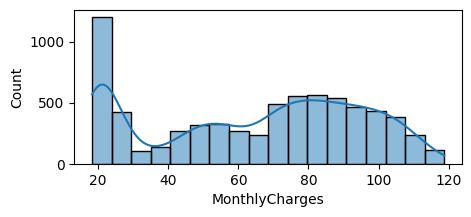

In [ ]:
# if numeric check the distribution
# by using historgram
plt.figure(figsize=(5,2))
sns.histplot(data,x='MonthlyCharges',kde=True)
plt.show()

In [ ]:
#find skew
# skew = [-0.5,0.5] ---> normal
# skew > 0.5 ---> right skew
# skew < -0.5 ---> left skew
data.loc[:,'MonthlyCharges'].skew()

np.float64(-0.22028439456532767)

Since skewness is within [-0.5,0.5] the distribution is normal so replace with mean

In [ ]:
#find mean
data.loc[:,'MonthlyCharges'].mean()

np.float64(64.74958102542253)

In [ ]:
#replace with mean
data.loc[:,'MonthlyCharges']=data.loc[:,'MonthlyCharges'].fillna(data.loc[:,'MonthlyCharges'].mean())

In [ ]:
data.loc[:,'MonthlyCharges'].isnull().sum()

np.int64(0)

TotalCharges

In [ ]:
#check the data type
data.loc[:,'TotalCharges'].dtype

dtype('O')

In [ ]:
#type casting: converting one data type to other
data.loc[:,'Total_Charges'] = pd.to_numeric(data.loc[:,'TotalCharges'], errors='coerce')
#coerce: converts empty string to null/nan

In [ ]:
data.loc[:,'Total_Charges'].dtypes

dtype('float64')

In [ ]:
#drop old column
data.drop(columns='TotalCharges',inplace=True)

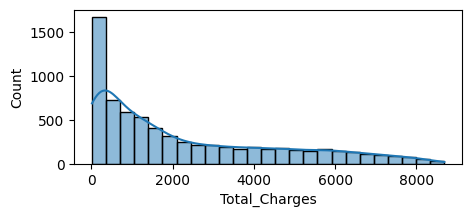

In [ ]:
# if numeric check the distribution
# by using historgram
plt.figure(figsize=(5,2))
sns.histplot(data,x='Total_Charges',kde=True)
plt.show()

In [ ]:
#find skew
# skew = [-0.5,0.5] ---> normal
# skew > 0.5 ---> right skew
# skew < -0.5 ---> left skew
data.loc[:,'Total_Charges'].skew()

np.float64(0.9616058347613503)

In [ ]:
#right skewed
#find median
data.loc[:,'Total_Charges'].median()

1397.3

In [ ]:
#fill with median
data.loc[:,'Total_Charges']=data.loc[:,'Total_Charges'].fillna(data.loc[:,'Total_Charges'].median())

In [ ]:
data.loc[:,'MonthlyCharges'].isnull().sum()

np.int64(0)

In [ ]:
data.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
#check for duplicates
data.duplicated().sum()

np.int64(22)

## **Exploratory Data Analysis (EDA)**

### **1. Univariate Analysis**

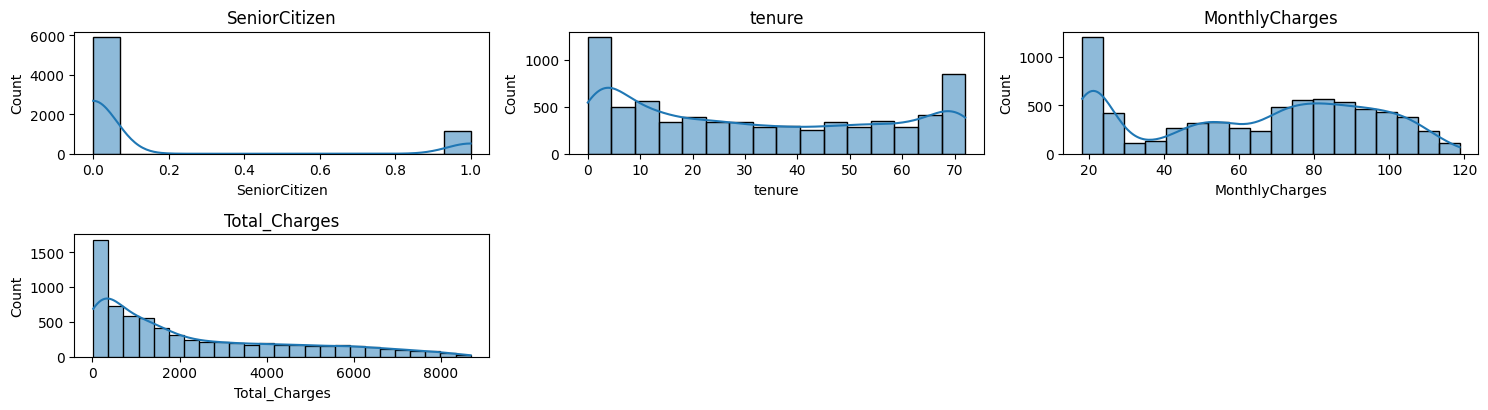

In [ ]:
# Distribution of numerical features (Histogram)
num_cols = data.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(10, 3, i)   # adjust rows, cols based on count
    sns.histplot(data[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

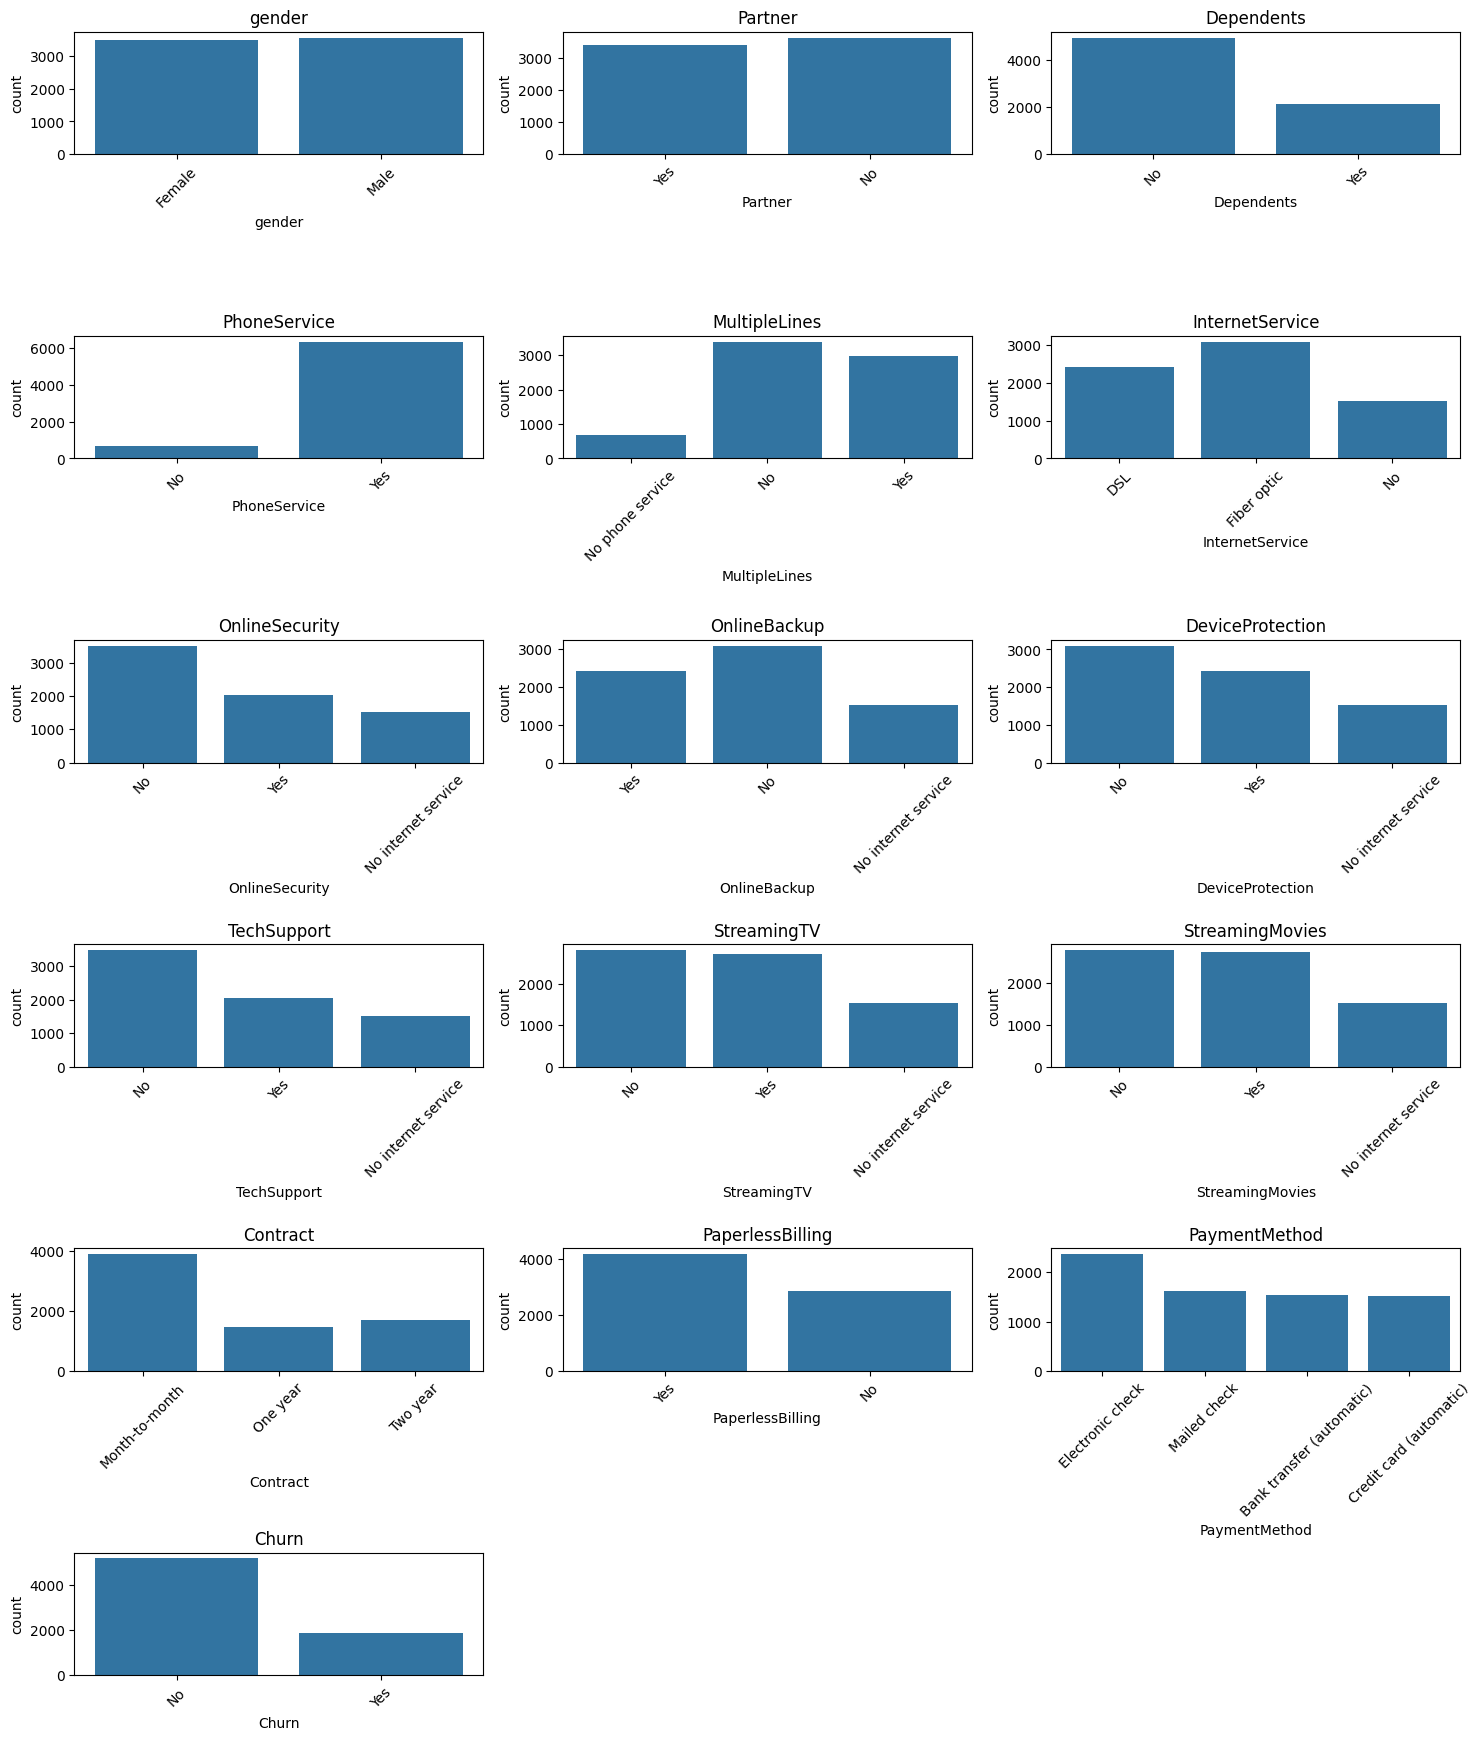

In [ ]:
# Distribution of categorical features (Countplot)
cat_cols = data.select_dtypes(include=['object'])

plt.figure(figsize=(15, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(7, 3, i)
    sns.countplot(x=data[col])
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Insights:
* The SeniorCitizen column is a binary categorical feature.
* The tenure plot reveals a "U-shaped" or bimodal distribution. There is a massive spike of customers in their very first month (0–5 months) and another significant spike of highly loyal customers (near 70+ months).

### **2. Bivariate Analysis**

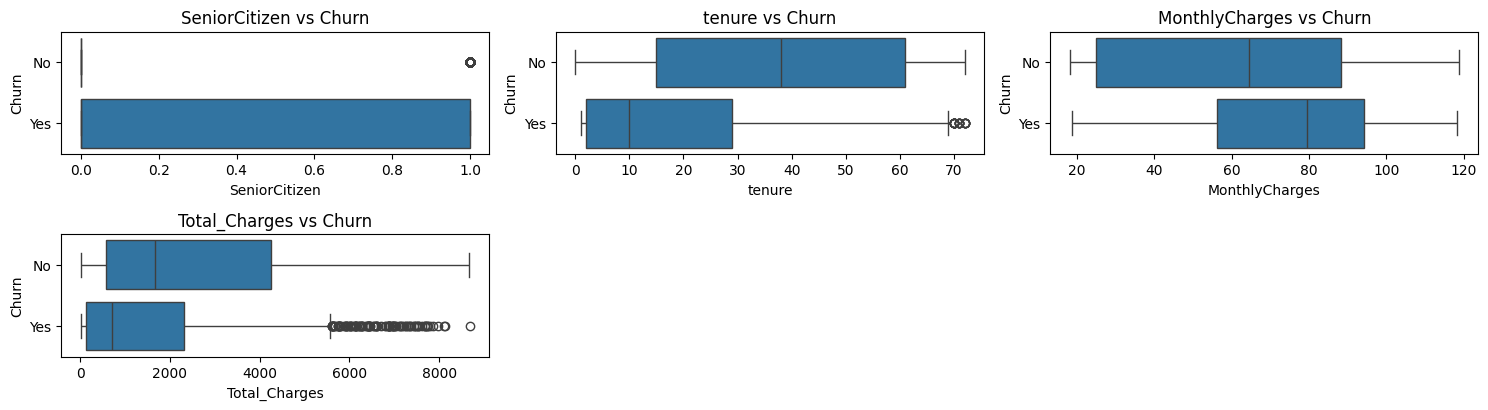

In [ ]:
# Churn vs numerical features
plt.figure(figsize=(15, 20))

for i, col in enumerate(num_cols, 1):
    plt.subplot(10, 3, i)
    sns.boxplot(x=col, y='Churn', data=data)
    plt.title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

Insights:
* Tenure is the strongest predictor of churn
* High cost + new customers = highest churn risk
* Retention strategies should focus on early-stage customers and high-paying users

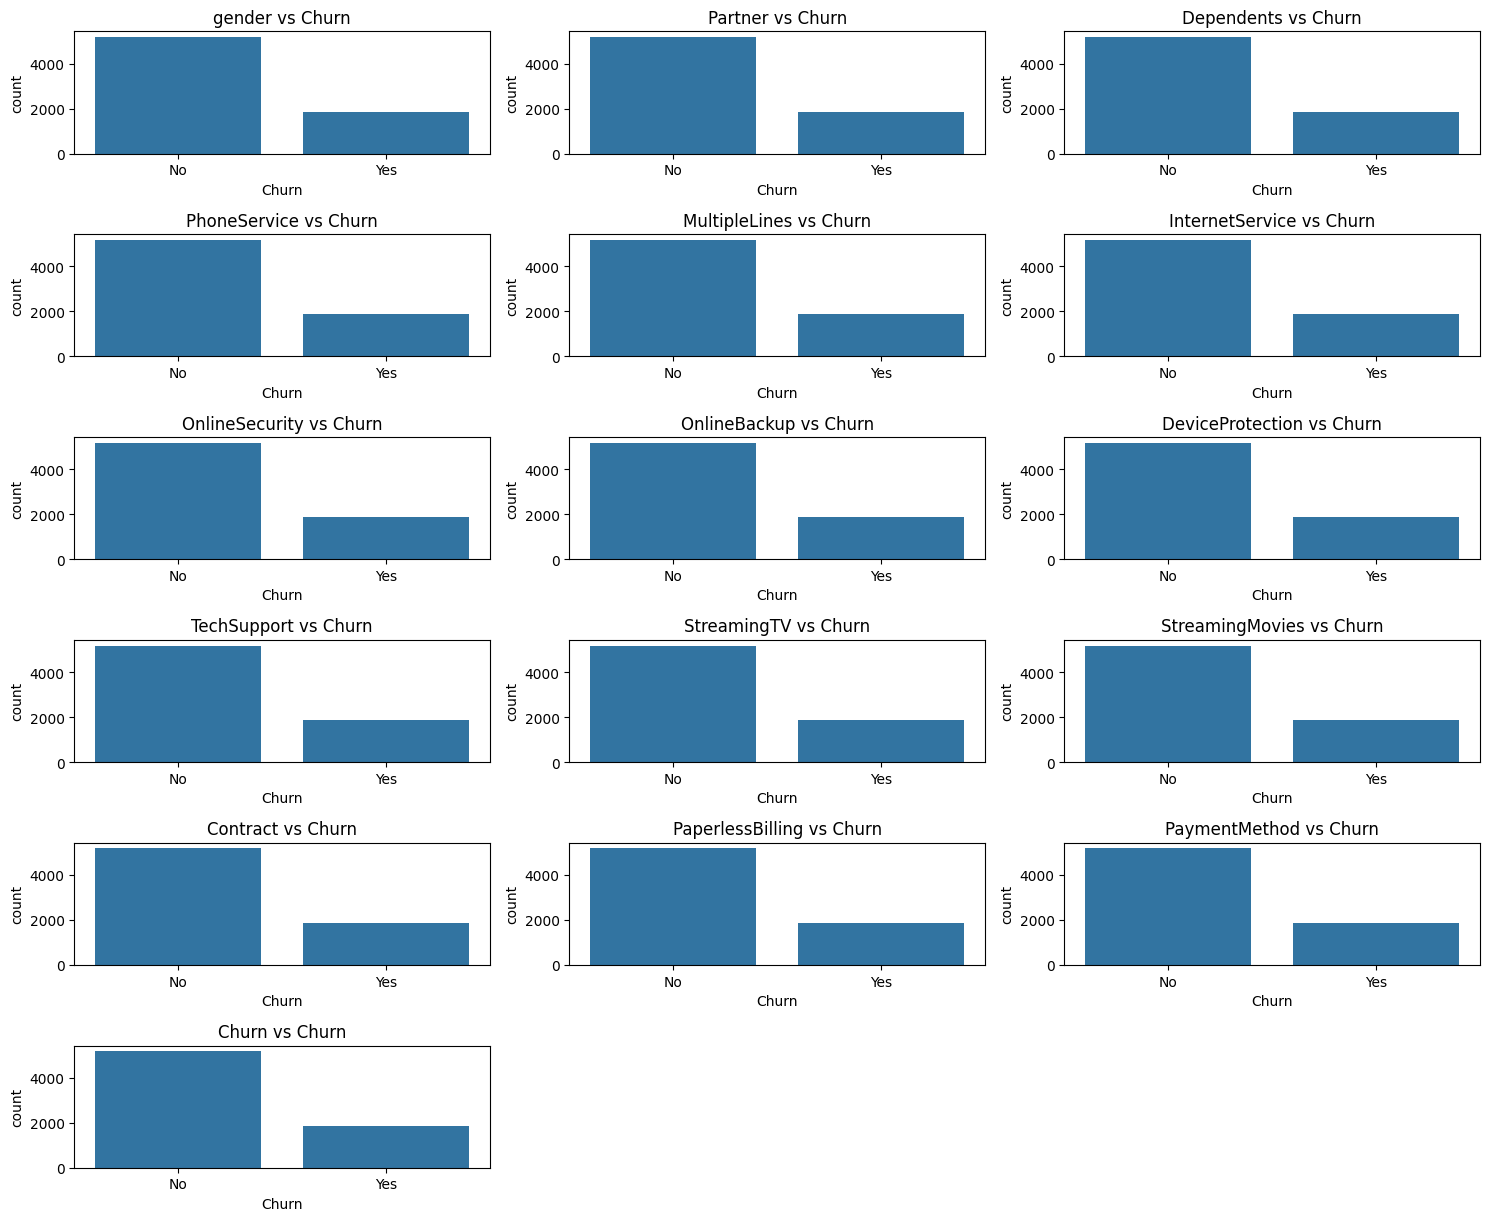

In [ ]:
# Churn vs categorical features
plt.figure(figsize=(15, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(10, 3, i)
    sns.countplot(x='Churn', data=data)
    plt.title(f"{col} vs Churn")

plt.tight_layout()
plt.show()

Insights:
* Services like TechSupport, OnlineSecurity, Backup → reduce churn significantly
* Entertainment services (Streaming) → do NOT impact churn much
* Focus business strategy on support & security features for retention

### **3. Multivariate Analysis**

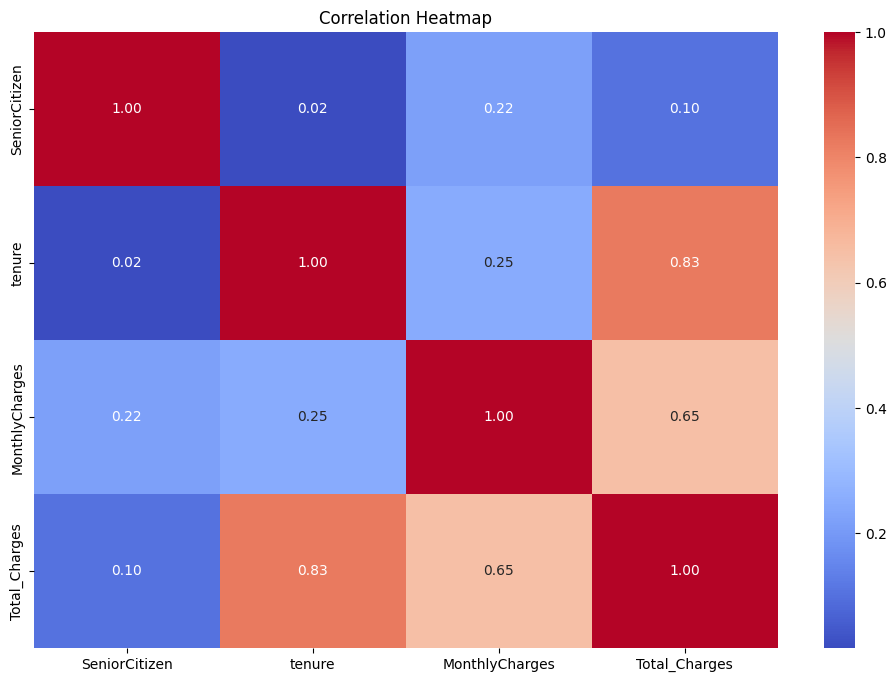

In [ ]:
# correlation heatmap

# Correlation matrix
corr = num_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Insights:
* TotalCharges is highly dependent on Tenure & MonthlyCharges
* No strong correlation among most independent variables → good for modeling

### **Detect and Handle Outliers**

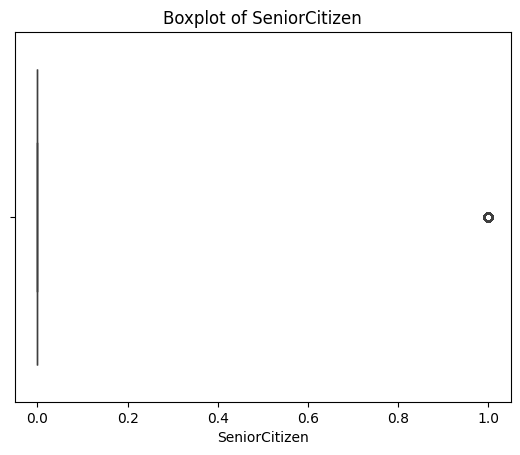

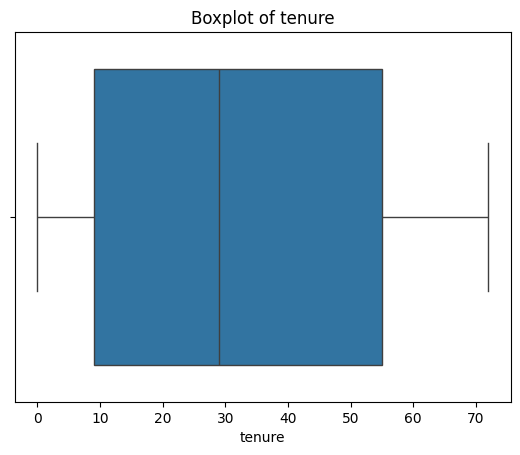

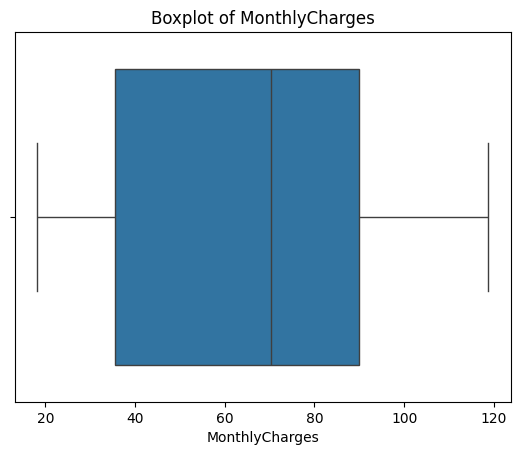

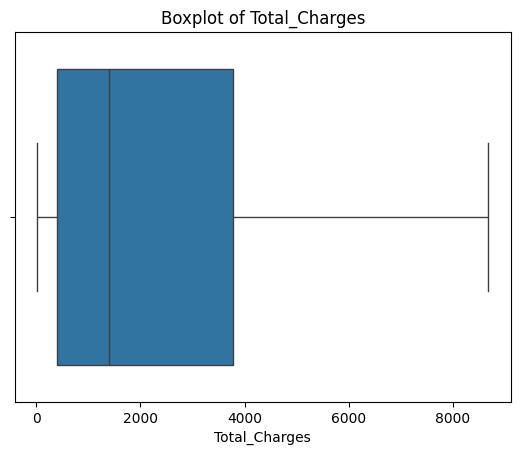

In [ ]:
for col in num_cols.columns:
    plt.figure()
    sns.boxplot(x=num_cols[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

Insight: there are no outliers

### **Encoding**

In [ ]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,Churn,Total_Charges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,No,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,No,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,Yes,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,No,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,Yes,151.65


In [ ]:
#label encoder
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Partner'] = le.fit_transform(data['Partner'])
data['Dependents'] = le.fit_transform(data['Dependents'])
data['PhoneService'] = le.fit_transform(data['PhoneService'])
data['OnlineSecurity'] = le.fit_transform(data['OnlineSecurity'])
data['OnlineBackup'] = le.fit_transform(data['OnlineBackup'])
data['DeviceProtection'] = le.fit_transform(data['DeviceProtection'])
data['TechSupport'] = le.fit_transform(data['TechSupport'])
data['StreamingTV'] = le.fit_transform(data['StreamingTV'])
data['StreamingMovies'] = le.fit_transform(data['StreamingMovies'])
data['PaperlessBilling'] = le.fit_transform(data['PaperlessBilling'])
data['Churn'] = le.fit_transform(data['Churn'])


In [ ]:
#one-hot encoding
data = pd.get_dummies(data, columns=['MultipleLines','InternetService','Contract','PaymentMethod','gender'], drop_first=True)

In [ ]:
data.dtypes

,0
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
OnlineSecurity,int64
OnlineBackup,int64
DeviceProtection,int64
TechSupport,int64
StreamingTV,int64


### **Feature engineering**

In [ ]:
from sklearn.model_selection import train_test_split

X = data.drop('Churn', axis=1)
y = data['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### **Scalling**

In [ ]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'Total_Charges']

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

### **Balancing Data**

In [ ]:
print(y_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [ ]:
# Apply SMOTE only on training data
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [ ]:
# verify balancing
print(y_train_sm.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


# **Model Training: Classification Models**

In [ ]:
# Import models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [ ]:
# Initialize Models
lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
knn = KNeighborsClassifier()
gb = GradientBoostingClassifier()
xgb = XGBClassifier()
svc = SVC()

In [ ]:
# Train Models
lr.fit(X_train_sm, y_train_sm)
dt.fit(X_train_sm, y_train_sm)
rf.fit(X_train_sm, y_train_sm)
knn.fit(X_train_sm, y_train_sm)
gb.fit(X_train_sm, y_train_sm)
xgb.fit(X_train_sm, y_train_sm)
svc.fit(X_train_sm, y_train_sm)

SVC()

In [ ]:
# Predictions
y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_xgb = xgb.predict(X_test)
y_pred_svc = svc.predict(X_test)

# **Model Evaluation**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Decision Tree:", accuracy_score(y_test, y_pred_dt))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("KNN:", accuracy_score(y_test, y_pred_knn))
print("Gradient Boosting:", accuracy_score(y_test, y_pred_gb))
print("XGBoosting:", accuracy_score(y_test, y_pred_xgb))
print("Support Vector Classifier:", accuracy_score(y_test, y_pred_svc))

Logistic Regression: 0.7601135557132718
Decision Tree: 0.6997870830376153
Random Forest: 0.7835344215755855
KNN: 0.7274662881476224
Gradient Boosting: 0.7735982966643009
XGBoosting: 0.7735982966643009
Support Vector Classifier: 0.7693399574166075


### **Improving Model Performance**

Further improvising model performances by

* choosing best k value for knn model,
* applying gini index for decision tree model,
* applying hyperparameters for random forest model
* hyperparameters for Gradient Boosting Classifier
* hyperparameters for XGBoosting Classifier
* hyperparameters for sv Classifier

[np.float64(0.23278921220723917), np.float64(0.2320794889992903), np.float64(0.21859474804826118), np.float64(0.22924059616749468), np.float64(0.21859474804826118), np.float64(0.21646557842441447), np.float64(0.21149751596877217), np.float64(0.20298083747338538), np.float64(0.20865862313697658)]


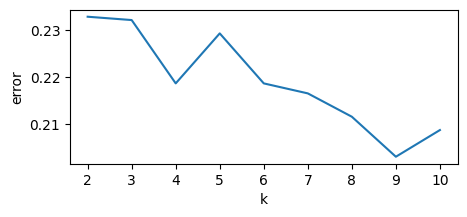

In [ ]:
# how to choose best k
error_rate = []
for k in range(2,11):
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_train, y_train)
  y_pred = model.predict(X_test)
  error_rate.append(np.mean(y_test!=y_pred))
print(error_rate)

plt.figure(figsize=(5,2))
plt.plot(range(2,11),error_rate)
plt.xlabel('k')
plt.ylabel('error')
plt.show()

In [ ]:
# use k = 9
knn_improved = KNeighborsClassifier(n_neighbors=9)
knn_improved.fit(X_train_sm, y_train_sm)
y_pred_knn_improved = knn_improved.predict(X_test)
print("KNN after improving:", accuracy_score(y_test, y_pred_knn_improved))
print("KNN before improving:", accuracy_score(y_test, y_pred_knn))

KNN after improving: 0.7402413058907026
KNN before improving: 0.7274662881476224


In [ ]:
# using gini index
dt_improved = DecisionTreeClassifier(random_state=42, criterion='gini',
                               max_depth=10,max_features='sqrt',
                               splitter='best',min_samples_leaf=3,
                               min_samples_split=5)
dt_improved.fit(X_train_sm, y_train_sm)
y_pred_dt_improved = dt_improved.predict(X_test)
print("Decision Tree after improving:", accuracy_score(y_test, y_pred_dt_improved))
print("Decision Tree before improving:", accuracy_score(y_test, y_pred_dt))

Decision Tree after improving: 0.7324343506032647
Decision Tree before improving: 0.6997870830376153


In [ ]:
# hyperparameters for random forest classifier
rf_improved = RandomForestClassifier(random_state=42, n_estimators=10, min_samples_split=5,
                                     min_samples_leaf=6, max_depth=50,max_features='sqrt',
                                     bootstrap=True, criterion='gini')
rf_improved.fit(X_train_sm, y_train_sm)
y_pred_rf_improved = rf_improved.predict(X_test)
print("Random Forest after improving:", accuracy_score(y_test, y_pred_rf_improved))
print("Random Forest before improving:", accuracy_score(y_test, y_pred_rf))

Random Forest after improving: 0.7693399574166075
Random Forest before improving: 0.7835344215755855


In [ ]:
# hyperparameters for Gradient Boosting Classifier
gb_improved = GradientBoostingClassifier(n_estimators=10,learning_rate=0.01,min_samples_split=6,min_samples_leaf=5,
                               max_depth=50,max_features='sqrt',loss='log_loss', random_state=42)
gb_improved.fit(X_train_sm, y_train_sm)
y_pred_gb_improved = gb_improved.predict(X_test)
print("Gradient Boosting Classifier after improving:", accuracy_score(y_test, y_pred_gb_improved))
print("Gradient Boosting Classifier before improving:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Classifier after improving: 0.7750177430801988
Gradient Boosting Classifier before improving: 0.7735982966643009


In [ ]:
# hyperparameters for XGBoosting classifier
xgb_improved = XGBClassifier(n_estimators=10,learning_rate=0.01,min_samples_split=6,min_samples_leaf=5,
                               max_depth=50,max_features='sqrt',loss='log_loss', random_state=42)
xgb_improved.fit(X_train_sm, y_train_sm)
y_pred_xgb_improved = xgb_improved.predict(X_test)
print("XGBoosting Classifier after improving:", accuracy_score(y_test, y_pred_xgb_improved))
print("XGBoosting Classifier before improving:", accuracy_score(y_test, y_pred_xgb))

XGBoosting Classifier after improving: 0.7650816181689141
XGBoosting Classifier before improving: 0.7735982966643009


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:30:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "loss", "max_features", "min_samples_leaf", "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [ ]:
# hyperparameters for sv Classifier
svc_improved = SVC(kernel ='rbf',gamma=0.01,C=20)
svc_improved.fit(X_train_sm, y_train_sm)
y_pred_svc_improved = svc_improved.predict(X_test)
print("Support Vector Classifier after improving:", accuracy_score(y_test, y_pred_svc_improved))
print("Support Vector Classifier before improving:", accuracy_score(y_test, y_pred_svc))

Support Vector Classifier after improving: 0.7672107877927609
Support Vector Classifier before improving: 0.7693399574166075


### **Model Evaluation with other metrices**

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix

# Store predictions in a dictionary
models = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt_improved,
    "Random Forest": y_pred_rf_improved,
    "KNN": y_pred_knn_improved,
    "Gradient Boosting" : y_pred_gb_improved,
    "XGBoosting" : y_pred_xgb_improved,
    "Support Vector Classifier" : y_pred_svc_improved
}

# Create empty dictionary for results
results = {
    "Accuracy": [],
    "Recall": [],
    "Precision": [],
    "F1 Score": [],
    "Confusion Matrix": []
}

# Calculate metrics
for model, y_pred in models.items():
    results["Accuracy"].append(accuracy_score(y_test, y_pred))
    results["Recall"].append(recall_score(y_test, y_pred))
    results["Precision"].append(precision_score(y_test, y_pred))
    results["F1 Score"].append(f1_score(y_test, y_pred))
    results["Confusion Matrix"].append(confusion_matrix(y_test, y_pred))

# Convert to DataFrame
df = pd.DataFrame(results, index=models.keys())
pd.set_option('display.max_columns', None)

print(df)

                           Accuracy    Recall  Precision  F1 Score  \
Logistic Regression        0.760114  0.766756   0.532588  0.628571   
Decision Tree              0.732434  0.753351   0.496466  0.598509   
Random Forest              0.769340  0.747989   0.547059  0.631937   
KNN                        0.740241  0.753351   0.506306  0.605603   
Gradient Boosting          0.775018  0.729223   0.557377  0.631823   
XGBoosting                 0.765082  0.678284   0.545259  0.604540   
Support Vector Classifier  0.767211  0.758713   0.543186  0.633110   

                                   Confusion Matrix  
Logistic Regression         [[785, 251], [87, 286]]  
Decision Tree               [[751, 285], [92, 281]]  
Random Forest               [[805, 231], [94, 279]]  
KNN                         [[762, 274], [92, 281]]  
Gradient Boosting          [[820, 216], [101, 272]]  
XGBoosting                 [[825, 211], [120, 253]]  
Support Vector Classifier   [[798, 238], [90, 283]]  


### **ROC-AUC Score and Curve**

LR AUC: 0.8489304605256348
DT AUC: 0.8111938058318755
RF AUC: 0.8474101255602596
KNN AUC: 0.8132951028393388
GB AUC: 0.8520940511557135
XGB AUC: 0.8309206372209054
SVC AUC: 0.8426213938948524


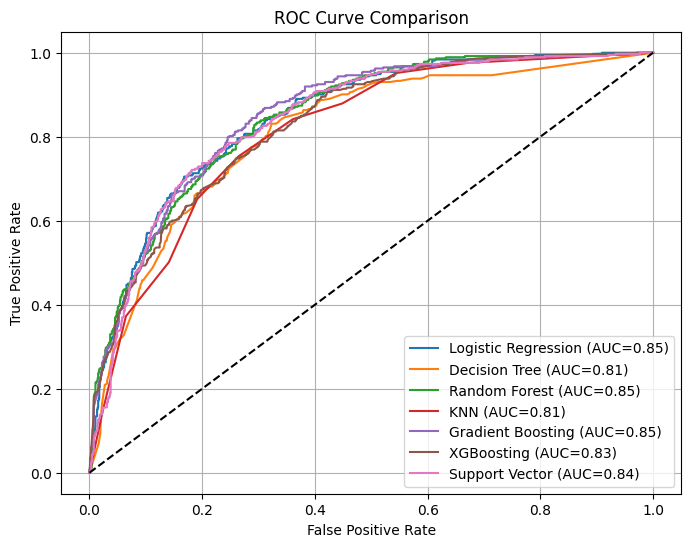

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

#Get probability scores
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_dt = dt_improved.predict_proba(X_test)[:,1]
y_prob_rf = rf_improved.predict_proba(X_test)[:,1]
y_prob_knn = knn_improved.predict_proba(X_test)[:,1]
y_prob_gb = gb_improved.predict_proba(X_test)[:,1]
y_prob_xgb = xgb_improved.predict_proba(X_test)[:,1]
y_prob_svc = svc_improved.decision_function(X_test)

#Calculate ROC-AUC score
print("LR AUC:", roc_auc_score(y_test, y_prob_lr))
print("DT AUC:", roc_auc_score(y_test, y_prob_dt))
print("RF AUC:", roc_auc_score(y_test, y_prob_rf))
print("KNN AUC:", roc_auc_score(y_test, y_prob_knn))
print("GB AUC:", roc_auc_score(y_test, y_prob_gb))
print("XGB AUC:", roc_auc_score(y_test, y_prob_xgb))
print("SVC AUC:", roc_auc_score(y_test, y_prob_svc))

#ROC Curve points
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_prob_svc)

#Plot ALL curves together
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, y_prob_lr):.2f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={roc_auc_score(y_test, y_prob_dt):.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, y_prob_rf):.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={roc_auc_score(y_test, y_prob_knn):.2f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={roc_auc_score(y_test, y_prob_gb):.2f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoosting (AUC={roc_auc_score(y_test, y_prob_xgb):.2f})")
plt.plot(fpr_svc, tpr_svc, label=f"Support Vector (AUC={roc_auc_score(y_test, y_prob_svc):.2f})")

plt.plot([0,1],[0,1],'k--')  # baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend(loc="lower right")
plt.grid()

plt.show()

### **Comparing Model Performance**

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

best_model = None
best_acc = 0
best_f1 = 0

for model, y_pred in models.items():
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"{model}: Accuracy = {acc:.4f}, F1 = {f1:.4f}")

    # Priority: Accuracy
    # Tie-breaker: F1 score
    if (acc > best_acc) or (acc == best_acc and f1 > best_f1):
        best_acc = acc
        best_f1 = f1
        best_model = model

print("\nBest Model:", best_model)
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

Logistic Regression: Accuracy = 0.7601, F1 = 0.6286
Decision Tree: Accuracy = 0.7324, F1 = 0.5985
Random Forest: Accuracy = 0.7693, F1 = 0.6319
KNN: Accuracy = 0.7402, F1 = 0.6056
Gradient Boosting: Accuracy = 0.7750, F1 = 0.6318
XGBoosting: Accuracy = 0.7651, F1 = 0.6045
Support Vector Classifier: Accuracy = 0.7672, F1 = 0.6331

Best Model: Gradient Boosting
Best Accuracy: 0.7750
Best F1 Score: 0.6318


### **Selecting best model**

According to comparision of models using various netrices **Gradient Boosting is the best model**:
* Gradient boosting model is capturing complex patterns well
* It is reducing errors step-by-step (how boosting works)
* It’s giving a good balance of bias + variance

### **Hyperparameter Tuning**

**Grid Search CV**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
# Initialize the model
gbc = GradientBoostingClassifier(random_state=42)

# Define the parameter grid
param_grid_gbc = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.8, 1.0] # Percentage of samples used per tree
}

# Initialize Grid Search
grid_gbc = GridSearchCV(estimator=gbc,
                        param_grid=param_grid_gbc,
                        cv=3,
                        n_jobs=-1,
                        verbose=2,
                        scoring='accuracy')

# Fit the model
grid_gbc.fit(X_train_sm, y_train_sm)

# Results
print("Best Parameters (Gradient Boosting):", grid_gbc.best_params_)
print("Best Score:", grid_gbc.best_score_)

Fitting 3 folds for each of 54 candidates, totalling 162 fits
Best Parameters (Gradient Boosting): {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 1.0}
Best Score: 0.8180332842619444


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize the Gradient Boosting Classifier
model = GradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=7,
    max_features=None,
    n_estimators=100,
    subsample=1.0,
    random_state=42 )

#fit model
model.fit(X_train_sm, y_train_sm)

# Make predictions
y_pred = model.predict(X_test)

In [ ]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[852 184]
 [116 257]]
Accuracy:  0.78708303761533
Recall:  0.6890080428954424
Precision:  0.5827664399092971
f1_score:  0.6314496314496314


**Randomised Search CV**

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Initialize the model
gbc = GradientBoostingClassifier(random_state=42)

# Define the parameter distribution
param_dist_gbc = {
    'n_estimators': randint(100, 500),        # Randomly pick between 100 and 500
    'learning_rate': uniform(0.01, 0.2),      # Randomly pick between 0.01 and 0.21
    'max_depth': [3, 4, 5, 6],                # Specific list of depths
    'subsample': uniform(0.6, 0.4),           # Randomly pick between 0.6 and 1.0
    'max_features': ['sqrt', 'log2', None]
}

# Initialize Random Search
random_gbc = RandomizedSearchCV(estimator=gbc,
                                param_distributions=param_dist_gbc,
                                n_iter=20,
                                cv=3,
                                n_jobs=-1,
                                verbose=2,
                                random_state=42,
                                scoring='accuracy')

# Fit the model
random_gbc.fit(X_train, y_train)

# Results
print("Best Parameters (Random Search):", random_gbc.best_params_)
print("Best Score:", random_gbc.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters (Random Search): {'learning_rate': np.float64(0.0430533878126005), 'max_depth': 3, 'max_features': None, 'n_estimators': 108, 'subsample': np.float64(0.908897907718663)}
Best Score: 0.8022719204827832


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
import numpy as np

# Initialize the Gradient Boosting Classifier using = instead of :
model = GradientBoostingClassifier(
    learning_rate=0.0430533878126005,
    max_depth=3,
    max_features=None,
    n_estimators=108,
    subsample=0.908897907718663,
    random_state=42 # Added for consistency
)

# Fit the model on your oversampled training data
model.fit(X_train_sm, y_train_sm)

# Make predictions
y_pred = model.predict(X_test)

In [ ]:
print("confusion matrix\n", confusion_matrix(y_test,y_pred))
print("Accuracy: " ,accuracy_score(y_test,y_pred))
print('Recall: ',recall_score(y_test,y_pred))
print('Precision: ',precision_score(y_test,y_pred))
print('f1_score: ',f1_score(y_test,y_pred))

confusion matrix
 [[786 250]
 [ 77 296]]
Accuracy:  0.7679205110007097
Recall:  0.7935656836461126
Precision:  0.5421245421245421
f1_score:  0.6441784548422198


### **Selecting Best Model**

Based on the various evaluation metrices and model performances, Gradient Boosting Classifier is the best mode with:
* confusion matrix: <br>
 [[852 184]<br>
 [116 257]]
* Accuracy:  0.78708303761533
* Recall:  0.6890080428954424
* Precision:  0.5827664399092971
* f1_score:  0.6314496314496314

### **Final Insights**

Key Factors Influencing Churn
* High monthly charges → Higher churn
* Month-to-month contracts → Higher churn
* No tech support → Higher churn
* Short tenure → Higher churn

Business Recommendations
* Offer long-term contract discounts
* Improve customer support services
* Provide personalized retention offers
* Identify high-risk customers early
* Reduce churn through loyalty programs